In [1]:
import numpy as np
from scipy.stats import norm
from scipy.stats import poisson
import matplotlib.pyplot as plt

### 1. A nasty integral

Using Monte Carlo integration, check that

$$ \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

- Does the result converge with the number of samples? And how does the error go down?
- Do it many times. For a given $N$, how are the result distributed? We'll talk about model fitting at lenght later on, but for now try to fit it by hand with a parametrized model. (If N is large enough you should get something that looks *very* accurate! And if $N$ is small?)
- How does the distribution change if $N$ increases?

(Hint: think about sample mean and sample variance)


In [2]:
N = 1000
mu = 0.
sigma = 1.

In [3]:
result = lambda s: 2.*s**4

def integ(loc, scale, n):
    gauss = norm(loc, scale)
    x = np.abs(gauss.rvs(n))
    return np.mean(x**3)*np.sqrt(np.pi/2)*sigma

Text(0.5, 0, 'N')

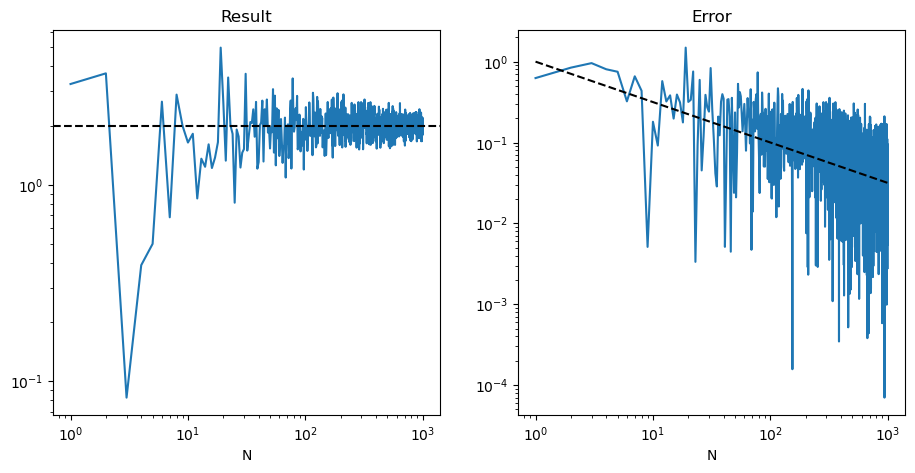

In [4]:
n_grid = np.arange(N)+1
sol = np.zeros(N)

for nn in n_grid:
    sol[nn-1] = integ(mu, sigma, nn)

fig, axs = plt.subplots(1, 2, figsize=(11, 5))

axs[0].loglog(n_grid, sol)
axs[0].axhline(result(sigma), c = 'black', ls = '--')
axs[0].set_title('Result')
axs[0].set_xlabel('N')

axs[1].loglog(n_grid, np.abs(sol-result(sigma))/result(sigma))
axs[1].loglog(n_grid, n_grid**(-1/2), c = 'black', ls = '--')
axs[1].set_title('Error')
axs[1].set_xlabel('N')

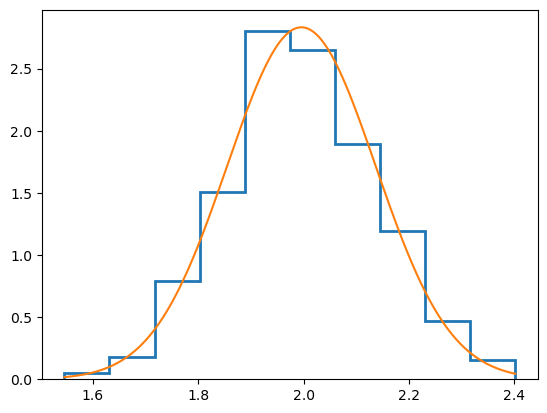

In [5]:
N = 1000
times = 1000
sol_t = np.zeros(times)

for t in range(times):
    sol_t[t] = integ(mu, sigma, N)

_, bins, _ = plt.hist(sol_t, density=True, histtype='step', lw = 2)
s_grid = np.linspace(bins[0], bins[-1], 2000)
fun = norm(np.mean(sol_t), np.std(sol_t))
plt.plot(s_grid, fun.pdf(s_grid))

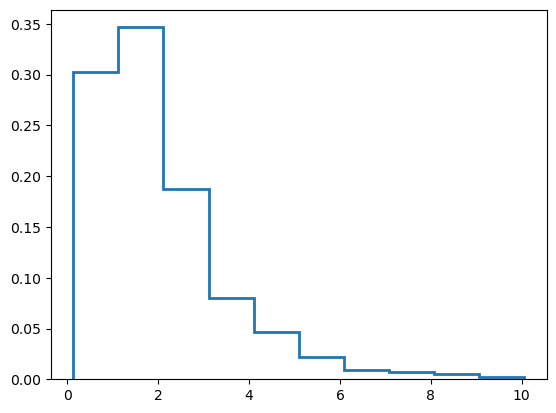

In [6]:
N = 10
times = 1000
sol_t = np.zeros(times)

for t in range(times):
    sol_t[t] = integ(mu, sigma, N)

_, bins, _ = plt.hist(sol_t, density=True, histtype='step', lw = 2)
s_grid = np.linspace(bins[0], bins[-1], 2000)